<a href="https://colab.research.google.com/github/palemsaikumar29-afk/saipalem.github.io/blob/main/RAG_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Embedding**

MODULE 1: Embeddings & Similarity Search Demo

Initializing OpenAI client...
Using OpenAI model: text-embedding-3-small
Embedding dimension: 1536

Loading support tickets...
Loaded 20 support tickets

SAMPLE TICKET:
ID: TICK-001
Title: Users unable to log in after password reset
Description: Multiple users reporting authentication failures after performing password reset. Error message: 'Invalid credentials'. Issue started after recent security patch deployment....
Category: Authentication
Priority: High

PART 1: Generating Embeddings

Generating embeddings for all tickets...
✓ Generated embeddings with shape: (20, 1536)
  (20 tickets × 1536 dimensions)
Searching for: 'Database is running very slowly'

Top Results:

#1 - Similarity Score: 0.5245
Ticket ID: TICK-010 | Category: Performance
Title: Dashboard loading extremely slowly
Description: Admin dashboard takes 30+ seconds to load. Browser DevTools show multiple slow database queries. Page becomes unresponsive during load. Affects all users with admin privileges.

#2 - Similarit

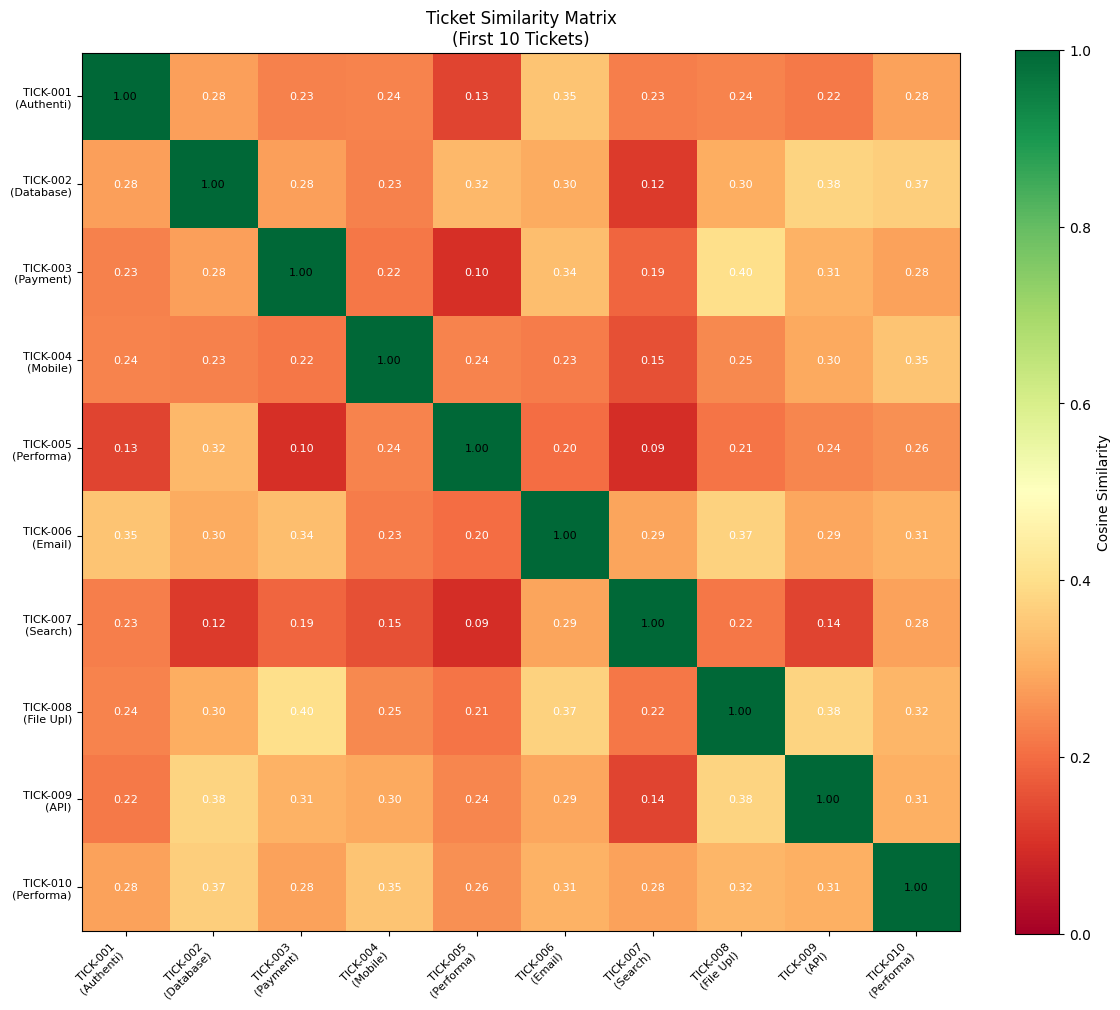


ALL SOLUTIONS COMPLETE!

Key Takeaways:
──────────────
1. Embeddings capture semantic meaning, not just keywords
2. Cosine similarity measures how related two texts are
3. Threshold filtering removes irrelevant results
4. Category filtering narrows search to specific domains
5. Batch API calls are 5-10x faster than single calls
6. Similarity matrices reveal relationships between documents

Next: Move on to Module 2 - Chunking & Vector Stores!



In [73]:
import json
import numpy as np              # For numerical operations on embedding vectors
import os
from openai import OpenAI       # OpenAI API client for generating embeddings
from sklearn.metrics.pairwise import cosine_similarity  # Measure similarity between vectors
import matplotlib.pyplot as plt # For visualizing embeddings
from dotenv import load_dotenv  # Load environment variables from .env file
from google.colab import userdata
import time # Import the time module

#INITIALIZE OPENAI CLIENT
load_dotenv()
print("Initializing OpenAI client...")
client = OpenAI(api_key=userdata.get('OPENAI_APIKEY'))

#EMBEDDING MODEL SELECTION
embedding_model = os.getenv('OPENAI_EMBEDDING_MODEL', 'text-embedding-3-small')
embedding_dim = 1536  # Number of dimensions in the embedding vector
print(f"Using OpenAI model: {embedding_model}")
print(f"Embedding dimension: {embedding_dim}")

#LOAD DATA: Support Tickets
# Load the synthetic tickets data
# Since we are inside the repository folder, the path is adjusted to find the data
print("\nLoading support tickets...")
with open('/content/sample_data/Data/synthetic_tickets.json', 'r') as f:
    tickets = json.load(f)
    print(f"Loaded {len(tickets)} support tickets")

# Display sample ticket - understand what we're working with
print("\n" + "="*80)
print("SAMPLE TICKET:")
print("="*80)
sample = tickets[0]
print(f"ID: {sample['ticket_id']}")
print(f"Title: {sample['title']}")
print(f"Description: {sample['description'][:200]}...")
print(f"Category: {sample['category']}")
print(f"Priority: {sample['priority']}")

print("\n" + "="*80)
print("PART 1: Generating Embeddings")
print("="*80)

# Prepare text for embedding
ticket_texts = [
    f"{ticket['title']}. {ticket['description']}"
    for ticket in tickets
]

# -----------------------------------------------------------------------------
# Generate embeddings via OpenAI API
# -----------------------------------------------------------------------------
# This is a BATCH call - we send all texts at once for efficiency
# The API returns one embedding per input text
#
# ‰ RATE LIMITS: Be aware of OpenAI's rate limits for production!
# ‰ COST: ~$0.02 per 1M tokens for text-embedding-3-small
# -----------------------------------------------------------------------------
print("\nGenerating embeddings for all tickets...")
response = client.embeddings.create(input=ticket_texts, model=embedding_model)

# Convert API response to NumPy array for mathematical operations
# Shape: (num_tickets, 1536) - each row is one ticket's embedding
embeddings = np.array([data.embedding for data in response.data])
print(f"✓ Generated embeddings with shape: {embeddings.shape}")
print(f"  ({len(tickets)} tickets × {embedding_dim} dimensions)")

# --- EXERCISE 1 START ---
# ============================================================================
# Task: Modify the search query here!
query = "Database is running very slowly"

print(f"Searching for: '{query}'")
# Embed the query
q_response = client.embeddings.create(input=[query], model=embedding_model)
q_emb = np.array([q_response.data[0].embedding])

# Calculate cosine similarity between the query and all ticket embeddings
similarities = cosine_similarity(q_emb, embeddings)[0]

# Get top 5 results
top_k = 5
top_indices = np.argsort(similarities)[::-1][:top_k]

print("\nTop Results:")
for rank, idx in enumerate(top_indices, 1):
    ticket = tickets[idx]
    score = similarities[idx]
    print(f"\n#{rank} - Similarity Score: {score:.4f}")
    print(f"Ticket ID: {ticket['ticket_id']} | Category: {ticket['category']}")
    print(f"Title: {ticket['title']}")
    print(f"Description: {ticket['description']}")


    # Exercise 2: Adjust the Number of Results (Easy)
# ============================================================================
print("\n" + "=" * 80)
print("EXERCISE 2: Adjust the Number of Results")
print("=" * 80)

# Solution: Change top_k from 5 to 10
top_k = 10  # Changed from 5
query = "Users can't login after changing password"
query_response = client.embeddings.create(input=[query], model=embedding_model)
query_embedding = np.array([query_response.data[0].embedding])
similarities = cosine_similarity(query_embedding, embeddings)[0]
top_indices = np.argsort(similarities)[::-1][:top_k]

print(f"\nQuery: '{query}'")
print(f"Showing top {top_k} results:")
print("-" * 50)

below_threshold_rank = None
for rank, idx in enumerate(top_indices, 1):
    score = similarities[idx]
    ticket = tickets[idx]
    print(f"#{rank} [{score:.4f}] {ticket['title']}")

    if below_threshold_rank is None and score < 0.5:
        below_threshold_rank = rank

print(f"\n→ Score drops below 0.5 at rank: {below_threshold_rank or 'Never (all above 0.5)'}")

# Exercise 3: Add a Similarity Threshold (Easy)
# ============================================================================
print("\n" + "=" * 80)
print("EXERCISE 3: Add a Similarity Threshold")
print("=" * 80)

# Solution: Add "if score < 0.5: continue" in the loop

def search_with_threshold(query_text, threshold=0.5):
    query_response = client.embeddings.create(input=[query_text], model=embedding_model)
    query_embedding = np.array([query_response.data[0].embedding])
    similarities = cosine_similarity(query_embedding, embeddings)[0]

    top_indices = np.argsort(similarities)[::-1][:10]

    print(f"\nQuery: '{query_text}' (threshold: {threshold})")
    print("-" * 50)

    count = 0
    for rank, idx in enumerate(top_indices, 1):
        ticket = tickets[idx]
        score = similarities[idx]

        # THE SOLUTION: Skip results below threshold
        if score < threshold:
            continue

        count += 1
        print(f"#{rank} [{score:.4f}] {ticket['title']}")

    if count == 0:
        print("No relevant tickets found above threshold.")
    else:
        print(f"\n→ {count} tickets above threshold")

# Call the function for Exercise 3
search_with_threshold("Users can't login after changing password", threshold=0.5)

# Exercise 4: Compare Two Queries (Easy)
# ============================================================================
print("\n" + "=" * 80)
print("EXERCISE 4: Compare Two Queries")
print("=" * 80)

# Solution: Just add this code to compare queries
query1 = "Login authentication failed"
query2 = "Slow database performance"

for q in [query1, query2]:
    response = client.embeddings.create(input=[q], model=embedding_model)
    q_emb = np.array([response.data[0].embedding])
    sims = cosine_similarity(q_emb, embeddings)[0]
    top_idx = np.argmax(sims)

    print(f"\nQuery: '{q}'")
    print(f"  Best match: {tickets[top_idx]['title']}")
    print(f"  Category: {tickets[top_idx]['category']}")
    print(f"  Score: {sims[top_idx]:.4f}")

# Exercise 5: Test Semantic Understanding (Medium)
# ============================================================================
print("\n" + "=" * 80)
print("EXERCISE 5: Test Semantic Understanding")
print("=" * 80)

# These mean the SAME thing but use DIFFERENT words
test_texts = [
    "User authentication failed",      # Original
    "Login credentials rejected",       # Same meaning, different words
    "Cannot sign in to account",        # Same meaning, different words
    "Database connection timeout",      # DIFFERENT topic
]

# Generate embeddings
response = client.embeddings.create(input=test_texts, model=embedding_model)
test_embeddings = np.array([data.embedding for data in response.data])

# Calculate all pairwise similarities
similarity_matrix = cosine_similarity(test_embeddings)

# Print results
print("\nSimilarity Matrix Analysis:")
print("-" * 60)
for i, text1 in enumerate(test_texts):
    for j, text2 in enumerate(test_texts):
        if i < j:  # Only print upper triangle
            sim = similarity_matrix[i][j]
            relation = "SIMILAR" if sim > 0.7 else "DIFFERENT"
            print(f"{sim:.3f} [{relation}] '{text1[:25]}...' vs '{text2[:25]}...')")

print("\n→ Notice: Auth/Login texts have HIGH similarity despite different words")
print("\n→ Notice: Database text has LOW similarity - different topic entirely")

# Exercise 6: Filter by Category (Medium)
# ============================================================================
print("\n" + "=" * 80)
print("EXERCISE 6: Filter by Category")
print("=" * 80)

def search_with_category(query, category_filter=None, top_k=5):
    """Search tickets, optionally filtering by category"""
    # Get query embedding
    response = client.embeddings.create(input=[query], model=embedding_model)
    query_emb = np.array([response.data[0].embedding])

    # Calculate similarities
    similarities = cosine_similarity(query_emb, embeddings)[0]

    # Get results with category filter
    results = []
    for idx in np.argsort(similarities)[::-1]:
        ticket = tickets[idx]

        # THE SOLUTION: Skip if category doesn't match filter
        if category_filter and ticket['category'] != category_filter:
            continue

        results.append((ticket, similarities[idx]))
        if len(results) >= top_k:
            break

    return results

# Call the function for Exercise 6 and print results
print("\nSearching for 'login problems' filtered by 'Authentication' category:")
filtered_results = search_with_category("login problems", category_filter="Authentication", top_k=3)

if filtered_results:
    for rank, (ticket, score) in enumerate(filtered_results, 1):
        print(f"\n#{rank} - Similarity Score: {score:.4f}")
        print(f"Ticket ID: {ticket['ticket_id']} | Category: {ticket['category']}")
        print(f"Title: {ticket['title']}")
        print(f"Description: {ticket['description']}")
else:
    print("No results found for the given query and category filter.")

print("\nSearching for 'slow database' filtered by 'Performance' category:")
filtered_results_2 = search_with_category("slow database", category_filter="Performance", top_k=3)

if filtered_results_2:
    for rank, (ticket, score) in enumerate(filtered_results_2, 1):
        print(f"\n#{rank} - Similarity Score: {score:.4f}")
        print(f"Ticket ID: {ticket['ticket_id']} | Category: {ticket['category']}")
        print(f"Title: {ticket['title']}")
        print(f"Description: {ticket['description']}")
else:
    print("No results found for the given query and category filter.")


print("\nAll categories:")
for ticket, score in search_with_category("login problem"):
    print(f"  {score:.3f} [{ticket['category']}] {ticket['title']}")

print("\nOnly 'Authentication' category:")
for ticket, score in search_with_category("login problem", category_filter="Authentication"):
    print(f"  {score:.3f} [{ticket['category']}] {ticket['title']}")


# Exercise 7: Batch vs Single Embedding (Medium)
# ============================================================================
print("\n" + "=" * 80)
print("EXERCISE 7: Batch vs Single Embedding")
print("=" * 80)

batch_texts = [
    "Password reset not working",
    "Database connection timeout",
    "App crashes on startup",
    "Payment declined error",
    "Email notifications delayed",
]

# Method 1: SLOW - One API call per text
print("\nMethod 1: Single API calls...")
start = time.time()
for text in batch_texts:
    response = client.embeddings.create(input=[text], model=embedding_model) # Changed 'model' to 'embedding_model'
time_slow = time.time() - start
print(f"  Time: {time_slow:.2f} seconds")

# Method 2: FAST - One API call for all texts
print("\nMethod 2: Batch API call...")
start = time.time()
response = client.embeddings.create(input=batch_texts, model=embedding_model) # Changed 'model' to 'embedding_model'
time_fast = time.time() - start
print(f"  Time: {time_fast:.2f} seconds")

# Compare
speedup = time_slow / time_fast if time_fast > 0 else float('inf')
print(f"\n✓ Batch is {speedup:.1f}x faster!")
print("  Always batch your embeddings in production!")

# Bonus: Similarity Matrix Heatmap (Challenge)
# ============================================================================
print("\n" + "=" * 80)
print("BONUS: Similarity Matrix Heatmap")
print("=" * 80)

# Use first 10 tickets
sample_tickets = tickets[:10]
sample_texts = [t['title'] for t in sample_tickets]

# Generate embeddings
response = client.embeddings.create(input=sample_texts, model=embedding_model) # Corrected 'model' to 'embedding_model'
sample_embeddings = np.array([data.embedding for data in response.data])

# Compute similarity matrix
sim_matrix = cosine_similarity(sample_embeddings)

# Create heatmap
plt.figure(figsize=(12, 10))
plt.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(label='Cosine Similarity')

# Add labels
labels = [f"{t['ticket_id']}\n({t['category'][:8]})" for t in sample_tickets]
plt.xticks(range(10), labels, rotation=45, ha='right', fontsize=8)
plt.yticks(range(10), labels, fontsize=8)

# Add values to cells
for i in range(10):
    for j in range(10):
        plt.text(j, i, f'{sim_matrix[i, j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if sim_matrix[i, j] < 0.5 else 'black')

plt.title('Ticket Similarity Matrix\n(First 10 Tickets)')
plt.tight_layout()
plt.savefig('solution_similarity_heatmap.png', dpi=150, bbox_inches='tight')
print("✓ Saved as solution_similarity_heatmap.png")
plt.show()

# Summary
# ============================================================================
print("\n" + "=" * 80)
print("ALL SOLUTIONS COMPLETE!")
print("=" * 80)
print("""
Key Takeaways:
──────────────
1. Embeddings capture semantic meaning, not just keywords
2. Cosine similarity measures how related two texts are
3. Threshold filtering removes irrelevant results
4. Category filtering narrows search to specific domains
5. Batch API calls are 5-10x faster than single calls
6. Similarity matrices reveal relationships between documents

Next: Move on to Module 2 - Chunking & Vector Stores!
""")